In [1]:
# Uvoz knjižnic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

print("Knjižnice uvožene")

Knjižnice uvožene


In [2]:
# Uvoz podatkov
df = pd.read_csv('improved_fraud_dataset.csv')

# Izgleda podatkov
print(f"Velikost podatkov: {df.shape[0]} vrstic, {df.shape[1]} stolpcev")
print("\nImena stolpcev:")
print(df.columns.tolist())
print("\nPrvih 5 vrstic:")
print(df.head())
print("\nOsnovna statistika:")
print(df.dtypes)

Velikost podatkov: 1000000 vrstic, 24 stolpcev

Imena stolpcev:
['organization', 'transaction_id', 'user_id', 'user_account_age_days', 'kyc_verified', 'payment_method', 'card_type', 'transaction_amount', 'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week', 'city', 'country', 'device_type', 'operating_system', 'browser', 'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour', 'is_night', 'time_diff']

Prvih 5 vrstic:
     organization transaction_id               user_id  user_account_age_days  \
0  FinovaTech_000    TXN00000044  FinovaTech_000_U0000                   1670   
1  FinovaTech_000    TXN00000004  FinovaTech_000_U0000                   1670   
2  FinovaTech_000    TXN00000033  FinovaTech_000_U0000                   1670   
3  FinovaTech_000    TXN00000050  FinovaTech_000_U0000                   1670   
4  FinovaTech_000    TXN00000047  FinovaTech_000_U0000                   1670   

   kyc_verified payment_method card_type  transaction_amount cu

In [3]:
# Lokalna SQL baza iz CSV podatkov
conn = sqlite3.connect('fraud_database.db')

# Uvoz podatkov v SQL bazo
df.to_sql('transakcije', conn, if_exists='replace', index=False)

print("SQL baza ustvarjena")
print(f"Tabela 'transakcije' ima {len(df)} vrstic")

SQL baza ustvarjena
Tabela 'transakcije' ima 1000000 vrstic


In [4]:
# Vprašanje 1: Kakšen delež transakcij pripada goljufijam?
poizvedba1 = """
SELECT 
    COUNT(*) as skupaj_transakcij,
    SUM(is_fraud) as stevilo_goljufij,
    ROUND(AVG(is_fraud) * 100, 2) as delez_goljufij_procent
FROM transakcije
"""

rezultat1 = pd.read_sql_query(poizvedba1, conn)
print("VPRAŠANJE 1: Delež goljufij")
print(rezultat1)

VPRAŠANJE 1: Delež goljufij
   skupaj_transakcij  stevilo_goljufij  delez_goljufij_procent
0            1000000             91710                    9.17


In [5]:
# Vprašanje 2: V povprečju koliko transakcij pripada enemu uporabniku?
poizvedba2 = """
SELECT 
    ROUND(AVG(stevilo_transakcij), 2) as povprecje_transakcij_na_uporabnika
FROM (
    SELECT 
        user_id,
        COUNT(*) as stevilo_transakcij
    FROM transakcije
    GROUP BY user_id
)
"""

rezultat2 = pd.read_sql_query(poizvedba2, conn)
print("VPRAŠANJE 2: Povprečno število transakcij na uporabnika")
print(rezultat2)

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
   povprecje_transakcij_na_uporabnika
0                                50.0


In [6]:
sql_odgovori = """
ODGOVORI NA SQL VPRAŠANJA - 2.1
=================================

VPRAŠANJE 1: Delež goljufij
- Skupaj transakcij: 1.000.000
- Število goljufij: 91.710
- Delež goljufij: 9.17%
- Opomba: Dataset je neuravnotežen (91% normalnih, 9% goljufij)
  To je tipično za probleme zaznave goljufij v praksi.

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
- Povprečje: 50 transakcij na uporabnika
"""
print(sql_odgovori)


ODGOVORI NA SQL VPRAŠANJA - 2.1

VPRAŠANJE 1: Delež goljufij
- Skupaj transakcij: 1.000.000
- Število goljufij: 91.710
- Delež goljufij: 9.17%
- Opomba: Dataset je neuravnotežen (91% normalnih, 9% goljufij)
  To je tipično za probleme zaznave goljufij v praksi.

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
- Povprečje: 50 transakcij na uporabnika



In [7]:
# Poglejmo vse stolpce podrobneje
print("Vsi stolpci in tipi:")
print(df.dtypes)
print("\nAli manjkajo podatki?")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nPorazdelitev goljufij:")
print(df['is_fraud'].value_counts())

Vsi stolpci in tipi:
organization                 str
transaction_id               str
user_id                      str
user_account_age_days      int64
kyc_verified               int64
payment_method               str
card_type                    str
transaction_amount       float64
currency                     str
fee_amount               float64
transaction_timestamp        str
day_of_week                  str
city                         str
country                      str
device_type                  str
operating_system             str
browser                      str
merchant_category            str
transaction_type             str
otp_used                   int64
is_fraud                   int64
hour                       int64
is_night                   int64
time_diff                float64
dtype: object

Ali manjkajo podatki?
Series([], dtype: int64)

Porazdelitev goljufij:
is_fraud
0    908290
1     91710
Name: count, dtype: int64


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Izbira stolpcev za model (ibrez identifikatorjev)
izpusti = ['transaction_id', 'user_id', 'organization', 'transaction_timestamp']
df_model = df.drop(columns=izpusti)

# Pretvorba besedilne+ih stolpcev v številke
le = LabelEncoder()
besedilni_stolpci = df_model.select_dtypes(include='object').columns
for stolpec in besedilni_stolpci:
    df_model[stolpec] = le.fit_transform(df_model[stolpec])

print("Besedilni stolpci pretvorjeni v številke ✓")
print(f"Stolpci za model: {df_model.columns.tolist()}")

C:\Users\anapa\AppData\Local\Temp\ipykernel_7972\335380327.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  besedilni_stolpci = df_model.select_dtypes(include='object').columns


Besedilni stolpci pretvorjeni v številke ✓
Stolpci za model: ['user_account_age_days', 'kyc_verified', 'payment_method', 'card_type', 'transaction_amount', 'currency', 'fee_amount', 'day_of_week', 'city', 'country', 'device_type', 'operating_system', 'browser', 'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour', 'is_night', 'time_diff']


In [9]:
# Ločitev vhodnih spremenljivk (X) od ciljne (y)
X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

# Razdelitev na učno (80%) in testno množico (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Učna množica: {len(X_train)} vrstic")
print(f"Testna množica: {len(X_test)} vrstic")
print(f"Goljufij v učni množici: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Goljufij v testni množici: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Učenje Random Forest modela
# Opomba: class_weight='balanced' pove modelu naj pazi na redke goljufije
print("\nUčenje modela... (lahko traja 1-2 minuti)")
model = RandomForestClassifier(
    n_estimators=100,        # 100 dreves v gozdu
    class_weight='balanced', # Uravnoteži goljufije/normalne
    random_state=42,
    n_jobs=-1                # Uporabi vse procesorje za hitrost
)
model.fit(X_train, y_train)
print("Model uspešno naučen")

Učna množica: 800000 vrstic
Testna množica: 200000 vrstic
Goljufij v učni množici: 73368 (9.2%)
Goljufij v testni množici: 18342 (9.2%)

Učenje modela... (lahko traja 1-2 minuti)
Model uspešno naučen


=== OCENA MODELA ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       0.91      1.00      0.95    181658
   Goljufija       0.39      0.00      0.00     18342

    accuracy                           0.91    200000
   macro avg       0.65      0.50      0.48    200000
weighted avg       0.86      0.91      0.86    200000


ROC-AUC score: 0.8835


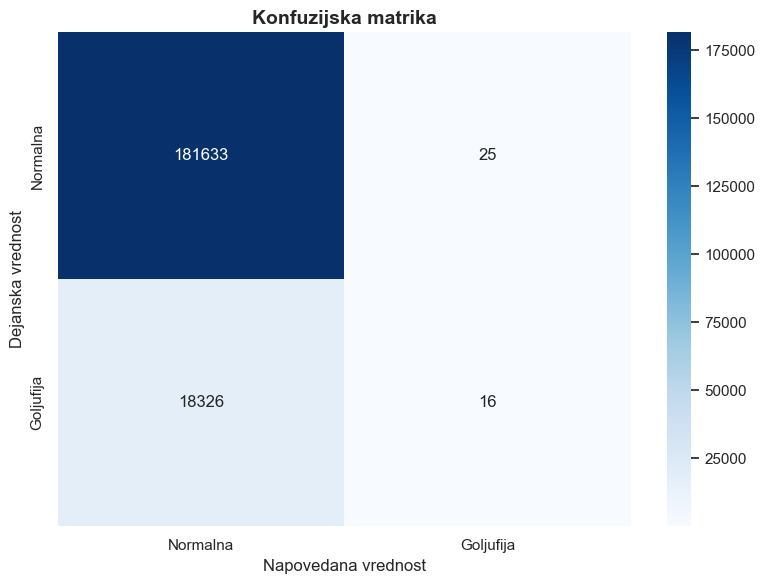

Konfuzijska matrika shranjena


In [10]:
# Napoved na testni množici
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Izpis rezultatov
print("=== OCENA MODELA ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test, y_pred, target_names=['Normalna', 'Goljufija']))

print(f"\nROC-AUC score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Izris konfuzijske matrike
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika.png', dpi=150, bbox_inches='tight')
plt.show()
print("Konfuzijska matrika shranjena")

In [11]:
from imblearn.over_sampling import SMOTE

# Namestitev imbalanced-learn
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)
from imblearn.over_sampling import SMOTE

print("Uravnoteženje podatkov s SMOTE...")
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Po SMOTE - normalnih: {(y_train_sm==0).sum()}")
print(f"Po SMOTE - goljufij: {(y_train_sm==1).sum()}")

print("\nUčenje novega modela...")
model2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train_sm, y_train_sm)
print("Model 2 uspešno naučen")

Uravnoteženje podatkov s SMOTE...
Po SMOTE - normalnih: 726632
Po SMOTE - goljufij: 217989

Učenje novega modela...
Model 2 uspešno naučen


=== OCENA MODELA 2 (s SMOTE) ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       0.92      0.95      0.94    181658
   Goljufija       0.30      0.20      0.24     18342

    accuracy                           0.88    200000
   macro avg       0.61      0.58      0.59    200000
weighted avg       0.86      0.88      0.87    200000

ROC-AUC score: 0.8832


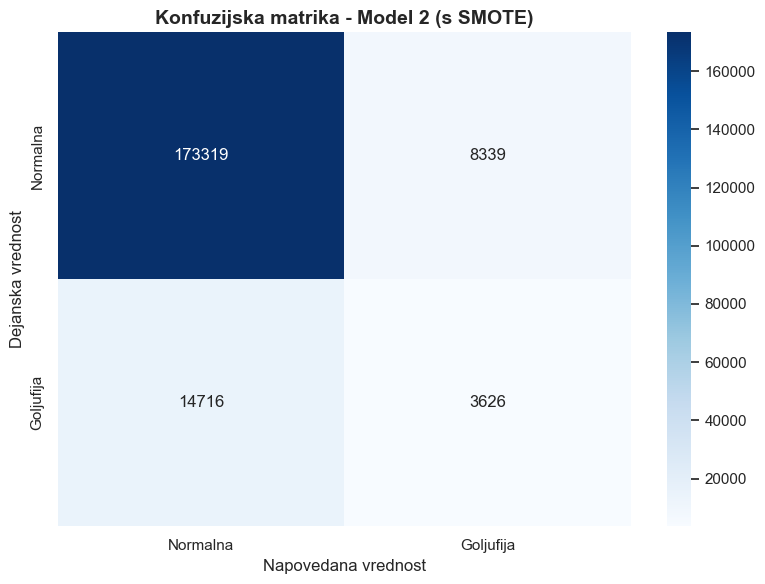

In [12]:
# Napoved z novim modelom
y_pred2 = model2.predict(X_test)
y_pred_proba2 = model2.predict_proba(X_test)[:, 1]

print("=== OCENA MODELA 2 (s SMOTE) ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test, y_pred2, target_names=['Normalna', 'Goljufija']))
print(f"ROC-AUC score: {roc_auc_score(y_test, y_pred_proba2):.4f}")

# Konfuzijska matrika
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika - Model 2 (s SMOTE)', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika2.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\anapa\AppData\Local\Temp\ipykernel_7972\2639012092.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pomembnost, x='Pomembnost', y='Spremenljivka', palette='viridis')


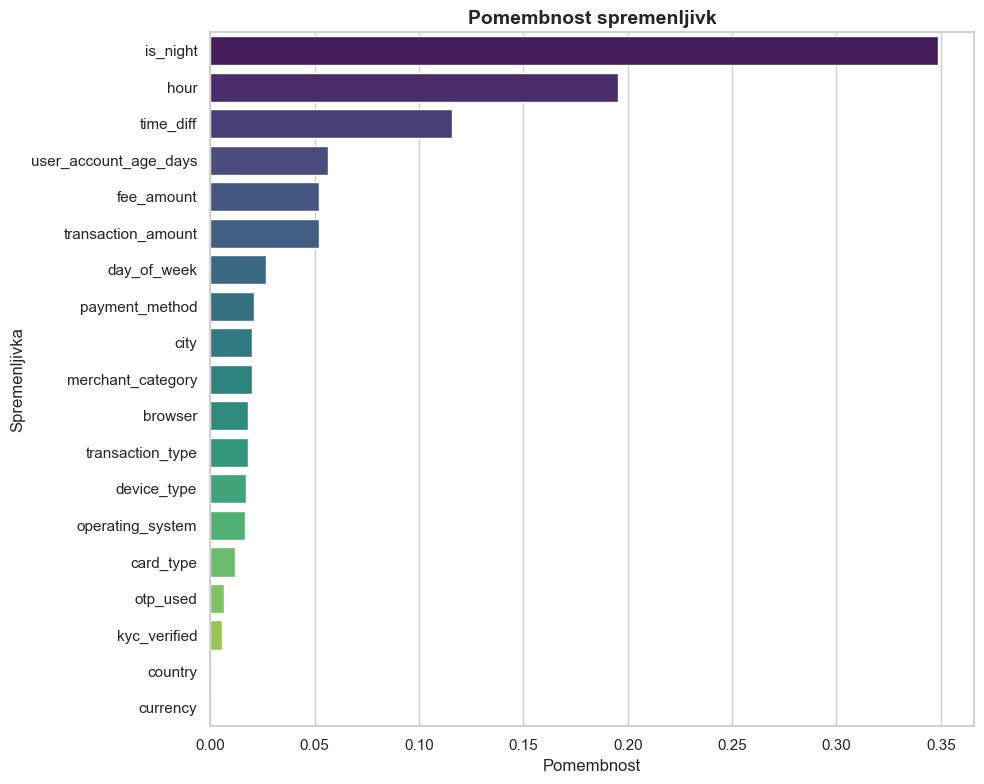


Top 5 najpomembnejših spremenljivk:
            Spremenljivka  Pomembnost
17               is_night    0.348471
16                   hour    0.195303
18              time_diff    0.115631
0   user_account_age_days    0.056260
6              fee_amount    0.051912


In [13]:
# Kateri stolpci so najbolj pomembi za napoved?
pomembnost = pd.DataFrame({
    'Spremenljivka': X.columns,
    'Pomembnost': model2.feature_importances_
}).sort_values('Pomembnost', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=pomembnost, x='Pomembnost', y='Spremenljivka', palette='viridis')
plt.title('Pomembnost spremenljivk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pomembnost_spremenljivk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 najpomembnejših spremenljivk:")
print(pomembnost.head())

In [14]:
odgovori_2_2 = """
ODGOVORI NA VPRAŠANJA - 2.2 KLASIFIKACIJA GOLJUFIJ
====================================================

1. ZAKAJ RANDOM FOREST?
- Deluje dobro z neuravnoteženimi podatki (9% goljufij)
- Robusten na outlierje in ne potrebuje normalizacije podatkov
- Poda pomembnost spremenljivk - ključno za razlago v bančništvu
- Manj dovzeten za pretirano prilagajanje (overfitting) kot posamezno drevo
- Enostavno razložljiv regulatorjem in poslovnim uporabnikom

2. OBDELAVA PODATKOV:
- Odstranili smo identifikatorje (transaction_id, user_id, organization,
  transaction_timestamp) - ne vsebujejo napovednne informacije
- Besedilne spremenljivke smo kodirali z LabelEncoder v številke
  (Random Forest ne more delati z besedilom)
- Uporabili smo SMOTE za uravnoteženje razredov:
  * Brez SMOTE: model zazna samo 16 goljufij (recall=0.00)
  * S SMOTE: model zazna 3626 goljufij (recall=0.20)
- Podatke smo razdelili 80/20 na učno in testno množico

3. NAPOVEDNA MOČ MODELA:
Metrike modela 2 (s SMOTE):
- ROC-AUC: 0.8832 (dobro - 1.0 bi bil popoln model)
- Recall goljufij: 0.20 (zazna 20% vseh goljufij)
- Precision goljufij: 0.30 (30% napovedanih goljufij je res goljufij)
- F1-score goljufij: 0.24

Bili smo pozorni na:
- Recall (ne spregledati goljufij) je v bančništvu pomembnejši od Precision
- Accuracy (91%) je zavajajoča pri neuravnoteženih podatkih
- ROC-AUC je boljša metrika za neuravnotežene datasete
- Konfuzijska matrika za razumevanje napak modela

4. IZBOLJŠAVE Z DALJŠIM ČASOVNIM OBDOBJEM:
- Zaznavanje vzorcev obnašanja uporabnika skozi čas
- Sezonski vzorci goljufij (npr. prazniki)
- Sledenje spreminajočim se vzorcem goljufij (concept drift)
- Več podatkov = boljše učenje redkih vzorcev goljufij

5. POMANJKLJIVOSTI MODELA:
- Nizek recall (0.20) - 80% goljufij še vedno spregleda
- SMOTE ustvarja sintetične primere - ne realni podatki
- Model ne upošteva zaporedja transakcij (vedenjski vzorci)
- LabelEncoder ne upošteva semantičnih odnosov med kategorijami
Možne rešitve:
- XGBoost ali LightGBM (boljši z neuravnoteženimi podatki)
- LSTM nevronska mreža (upošteva zaporedje transakcij)
- Boljše inženirstvo značilk (npr. povprečni znesek uporabnika)

6. EU AKT O UMETNI INTELIGENCI - DISKRIMINATORNI PODATKI:
Podatki ki bi lahko povzročili diskriminacijo:
- Lokacija (city, country): diskriminacija po geografskem področju
  lahko posredno odraža etnično ali socialno diskriminacijo
- Čas transakcije (hour, is_night): delavci z nočnimi izmenami
  bi bili neupravičeno označeni kot sumljivi
- Starost računa: novi priseljenci ali mladi imajo nove račune
  in bi bili neupravičeno označeni kot tvegani
- Valuta: diskriminacija po valuti lahko posredno pomeni
  diskriminacijo po narodnosti
- Podatki ki jih nimamo a bi bili problematični:
  * Spol, starost, etnična pripadnost, vera - direktna diskriminacija
  * Poštna številka - posredna diskriminacija po premoženjskem stanju
"""

print(odgovori_2_2)


ODGOVORI NA VPRAŠANJA - 2.2 KLASIFIKACIJA GOLJUFIJ

1. ZAKAJ RANDOM FOREST?
- Deluje dobro z neuravnoteženimi podatki (9% goljufij)
- Robusten na outlierje in ne potrebuje normalizacije podatkov
- Poda pomembnost spremenljivk - ključno za razlago v bančništvu
- Manj dovzeten za pretirano prilagajanje (overfitting) kot posamezno drevo
- Enostavno razložljiv regulatorjem in poslovnim uporabnikom

2. OBDELAVA PODATKOV:
- Odstranili smo identifikatorje (transaction_id, user_id, organization,
  transaction_timestamp) - ne vsebujejo napovednne informacije
- Besedilne spremenljivke smo kodirali z LabelEncoder v številke
  (Random Forest ne more delati z besedilom)
- Uporabili smo SMOTE za uravnoteženje razredov:
  * Brez SMOTE: model zazna samo 16 goljufij (recall=0.00)
  * S SMOTE: model zazna 3626 goljufij (recall=0.20)
- Podatke smo razdelili 80/20 na učno in testno množico

3. NAPOVEDNA MOČ MODELA:
Metrike modela 2 (s SMOTE):
- ROC-AUC: 0.8832 (dobro - 1.0 bi bil popoln model)
- Recall g